In [ ]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\_aromatic_2025_971_CClFHNO.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
1139,"Ethyl 2-butyramido-2-(4-chloroanilino)-3,3,3-t...",C15H18ClF3N2O3,366,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)NC(Nc1ccc(Cl)cc1)(C(=O)OCC)C(F)(F)F,CClFHNO
1146,"Ethyl 2-butyramido-2-(3,4-dichloroanilino)-3,3...",C15H17Cl2F3N2O3,400,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)NC(Nc1ccc(Cl)c(Cl)c1)(C(=O)OCC)C(F)(F)F,CClFHNO
1149,Ethyl 2-butyramido-2-[4-chloro-2-(trifluoromet...,C16H17ClF6N2O3,434,311764-37-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)NC(Nc1ccc(Cl)cc1C(F)(F)F)(C(=O)OCC)C(F...,CClFHNO
1151,2-Butyramido-2-[4-chloro-2-(trifluoromethyl)an...,C14H12ClF9N2O,430,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)NC(Nc1ccc(Cl)cc1C(F)(F)F)(C(F)(F)F)C(F...,CClFHNO
1254,Triflumizole,C15H15ClF3N3O,345,68694-11-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCOCC(=Nc1ccc(Cl)cc1C(F)(F)F)n2ccnc2,CClFHNO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181078,"1,2-Dichloro-4-fluoro-5-nitrobenzene",C6H2Cl2FNO2,209,2339-78-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,[O-][N+](=O)c1cc(Cl)c(Cl)cc1F,CClFHNO
181126,"2H-1,4-Benzodiazepin-2-one, 1,3-dihydro-1-(2-a...",C17H15ClFN3O,331,17617-59-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NCCN1C(=O)CN=C(c2ccccc2F)c3cc(Cl)ccc13,CClFHNO
181423,"Carbamic acid, N-(6-chloro-5-trifluoromethyl-3...",C10H6ClF3N2O2,278,288246-64-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,FC(F)(F)c1cc(NC(=O)OCC#C)cnc1Cl,CClFHNO
182306,Ethyl 4-chloro-3-trifluoromethylcarbanilate,C10H9ClF3NO2,267,18585-06-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F,CClFHNO


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd

# Assuming ms is your DataFrame
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  
c = 0

for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:

        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(971), np.int64(600)), y.shape: (np.int64(971),), w.shape: (np.int64(971),), ids: [0 1 2 ... 968 969 970], task_names: [0]>

In [ ]:
dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/C]': 4,
 '[/Cl]': 5,
 '[/N]': 6,
 '[/O]': 7,
 '[=Branch1]': 8,
 '[=Branch2]': 9,
 '[=C]': 10,
 '[=N]': 11,
 '[=O]': 12,
 '[=Ring1]': 13,
 '[=Ring2]': 14,
 '[Branch1]': 15,
 '[Branch2]': 16,
 '[C@@H1]': 17,
 '[C@H1]': 18,
 '[C@]': 19,
 '[C]': 20,
 '[Cl]': 21,
 '[F]': 22,
 '[N+1]': 23,
 '[NH1]': 24,
 '[N]': 25,
 '[O-1]': 26,
 '[O]': 27,
 '[P]': 28,
 '[Ring1]': 29,
 '[Ring2]': 30,
 '[S]': 31,
 '[\\C]': 32,
 '[\\N]': 33,
 '[\\O]': 34,
 '[nop]': 35}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 831
📦 Validation set size: 0
📦 Test set size: 140


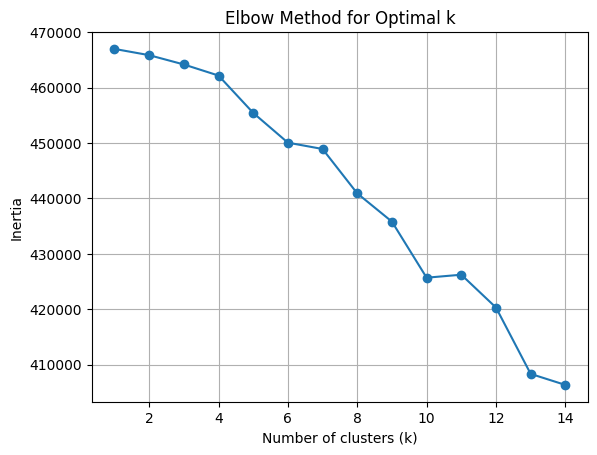

🔍 Elbow point detected at k = 1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [9]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=2,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(2):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (759, 600)
Cluster 1 shape: (72, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

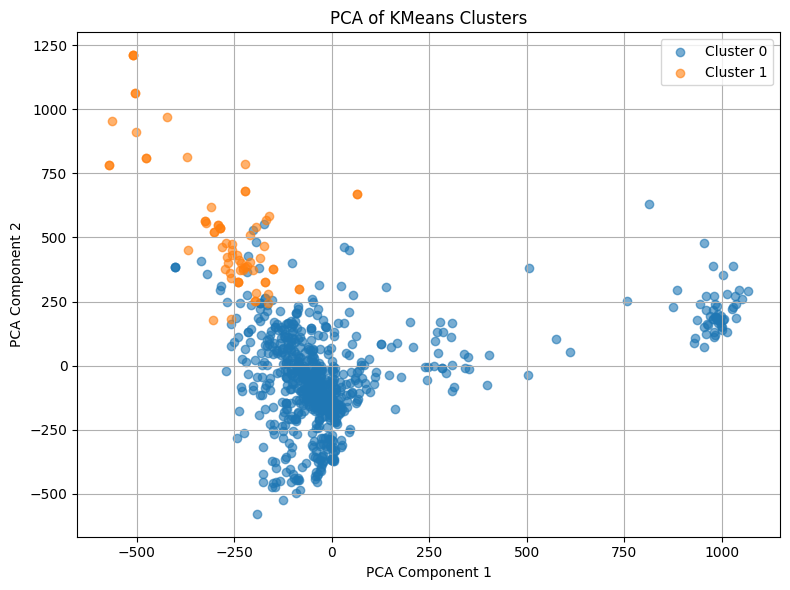

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [13]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_

Cluster 0: size = 126, shape = (126, 600)
Cluster 1: size = 14, shape = (14, 600)


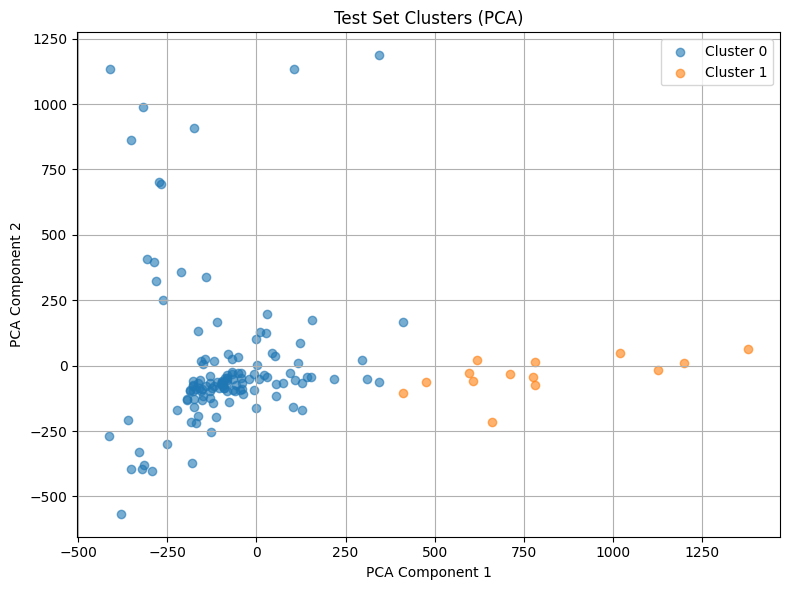

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(2):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.337016
Epoch 2/100 - Loss: 0.059368
Epoch 3/100 - Loss: 0.053835
Epoch 4/100 - Loss: 0.051416
Epoch 5/100 - Loss: 0.049499
Epoch 6/100 - Loss: 0.047485
Epoch 7/100 - Loss: 0.045206
Epoch 8/100 - Loss: 0.042877
Epoch 9/100 - Loss: 0.040547
Epoch 10/100 - Loss: 0.038424
Epoch 11/100 - Loss: 0.036311
Epoch 12/100 - Loss: 0.034212
Epoch 13/100 - Loss: 0.030448
Epoch 14/100 - Loss: 0.030233
Epoch 15/100 - Loss: 0.028063
Epoch 16/100 - Loss: 0.026544
Epoch 17/100 - Loss: 0.024649
Epoch 18/100 - Loss: 0.022924
Epoch 19/100 - Loss: 0.021407
Epoch 20/100 - Loss: 0.019837
Epoch 21/100 - Loss: 0.018775
Epoch 22/100 - Loss: 0.017215
Epoch 23/100 - Loss: 0.016027
Epoch 24/100 - Loss: 0.015098
Epoch 25/100 - Loss: 0.014003
Epoch 26/100 - Loss: 0.013132
Epoch 27/100 - Loss: 0.012378
Epoch 28/100 - Loss: 0.011698
Epoch 29/100 - Loss: 0.011114
Epoch 30/100 - Loss: 0.010448
Epoch 31/100 - Loss: 0.009805
Epoch 32/100 - Loss: 0.009485
Epoch 33/100 - Loss: 0.008901
Epoch 34/100 - Loss

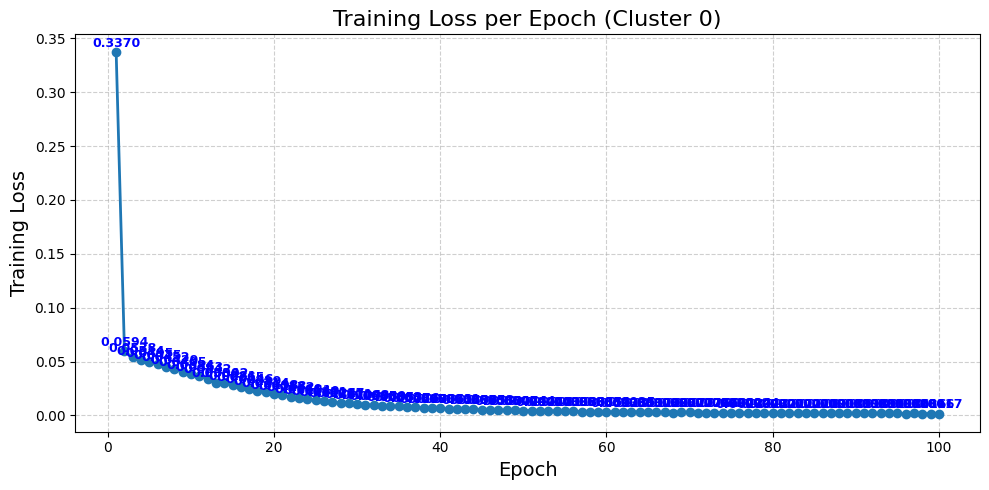

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\models_\model0000


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [16]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [17]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (126, 2664, 2)
Example prediction: [[1.00000000e+00 2.73250415e-15]
 [1.00000000e+00 3.83920140e-15]
 [1.00000000e+00 2.72407278e-16]
 ...
 [1.00000000e+00 1.37727301e-17]
 [1.00000000e+00 1.04096604e-16]
 [5.31061269e-17 1.00000000e+00]]


In [18]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [19]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [20]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CCOC(=O)C(=CNC1=CC=C(F)C(Cl)=C1)C(=O)OCC | True: CCOC(=O)C(=CNC1=CC=C(F)C(Cl)=C1)C(=O)OCC | Tanimoto: 1.000
[1] Pred: CCCCCCC(C)C=CCC | True: NNC(=O)C1CCN(CC1)C2=NC=C(C=C2Cl)C(F)(F)F | Tanimoto: 0.042
[2] Pred: FC(F)(F)C=C1C=C(Cl)C1(NC(C)OCCNC=NCN=N)CC | True: FC(F)(F)C1=CN(CCC(=O)NC2=CC=C(Cl)C=C2)C(=O)C=C1 | Tanimoto: 0.206
[3] Pred: [O-1]O[N+1](C)OC=CCC=C=CC | True: FC1=CC=C(C=C1Cl)N2C(=O)C=CC2=O | Tanimoto: 0.052
[4] Pred: COC1=NC(NC2=CC=C(OC(F)(F)Cl)C=C2)=NC(OC(C(F)(F)F)C(F)(F)F)=N1 | True: COC1=NC(NC2=CC=C(OC(F)(F)Cl)C=C2)=NC(OC(C(F)(F)F)C(F)(F)F)=N1 | Tanimoto: 1.000
[5] Pred: CCCCNC1=C2C(=O)C3=CC(Cl)=CC=C3N=C2CC(C1)C4=CC=C(C=C4)C(F)(F)F | True: CCCCNC1=C2C(=O)C3=CC(Cl)=CC=C3N=C2CC(C1)C4=CC=C(C=C4)C(F)(F)F | Tanimoto: 1.000
[6] Pred: FC(F)(Cl)OC1=CC=C(NC(=O)CCN2CCCC2)C=C1 | True: FC(F)(Cl)OC1=CC=C(NC(=O)CCN2CCCC2)C=C1 | Tanimoto: 1.000
[7] Pred: ON1C2=C(C(CC(C2)C3=CC=C(C=C3)C(F)(F)F)=NCCCN4CCCC4)C(=O)C5=CC(Cl)=CC=C15 | True: ON1C2=C(C(CC(C2)C3=CC=C(C=C3)C(F)(F)F)=NCCCN4

Epoch 1/100 - Loss: 1.572845
Epoch 2/100 - Loss: 0.238405
Epoch 3/100 - Loss: 0.088750
Epoch 4/100 - Loss: 0.077489
Epoch 5/100 - Loss: 0.066854
Epoch 6/100 - Loss: 0.056336
Epoch 7/100 - Loss: 0.049236
Epoch 8/100 - Loss: 0.045611
Epoch 9/100 - Loss: 0.043894
Epoch 10/100 - Loss: 0.041821
Epoch 11/100 - Loss: 0.039897
Epoch 12/100 - Loss: 0.038353
Epoch 13/100 - Loss: 0.036723
Epoch 14/100 - Loss: 0.034493
Epoch 15/100 - Loss: 0.033066
Epoch 16/100 - Loss: 0.030852
Epoch 17/100 - Loss: 0.029548
Epoch 18/100 - Loss: 0.027875
Epoch 19/100 - Loss: 0.026653
Epoch 20/100 - Loss: 0.024384
Epoch 21/100 - Loss: 0.023022
Epoch 22/100 - Loss: 0.021617
Epoch 23/100 - Loss: 0.020272
Epoch 24/100 - Loss: 0.018371
Epoch 25/100 - Loss: 0.017308
Epoch 26/100 - Loss: 0.016142
Epoch 27/100 - Loss: 0.014770
Epoch 28/100 - Loss: 0.013678
Epoch 29/100 - Loss: 0.012608
Epoch 30/100 - Loss: 0.011566
Epoch 31/100 - Loss: 0.011024
Epoch 32/100 - Loss: 0.009979
Epoch 33/100 - Loss: 0.009667
Epoch 34/100 - Loss

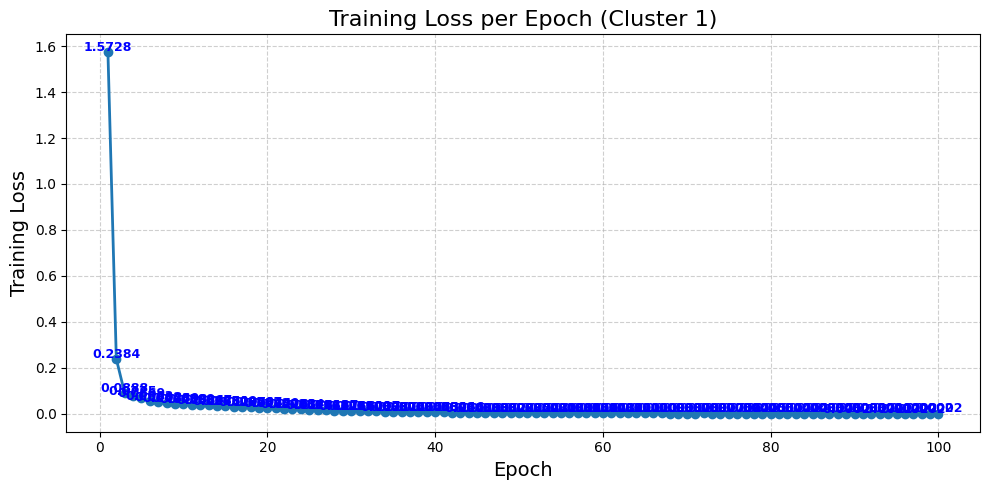

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\models_\model1111


In [21]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [22]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_971_CClFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (14, 2664, 2)
Example prediction: [[1.0000000e+00 1.0345647e-16]
 [1.0000000e+00 1.7030064e-21]
 [1.0000000e+00 6.1076700e-19]
 ...
 [1.0000000e+00 1.1134628e-16]
 [1.0000000e+00 4.4003858e-17]
 [2.3404079e-10 1.0000000e+00]]
[0] Pred: CCCC(=O)NC(NC1=CC=C(Cl)C(Cl)=C1)(C(=O)OCC)C(F)(F)F | True: CCCC(=O)NC(NC1=CC=C(Cl)C(Cl)=C1)(C(=O)OCC)C(F)(F)F | Tanimoto: 1.000
[1] Pred: CCCC(=O)NC(NC1=CC=C(Cl)C=C1C(F)(F)F)(C(=O)OCC)C(F)(F)F | True: CCCC(=O)NC(NC1=CC=C(Cl)C=C1C(F)(F)F)(C(=O)OCC)C(F)(F)F | Tanimoto: 1.000
[2] Pred: CC1=C(N(CCF)CCCl)C(=O)NC(=O)N1 | True: CC1=C(N(CCF)CCCl)C(=O)NC(=O)N1 | Tanimoto: 1.000
[3] Pred: CCCCCCCN=C1CC(CC2=C1C(=O)C3=CC(Cl)=CC=C3N2O)C4=CC=C(C=C4)C(F)(F)F | True: CCCCCCCN=C1CC(CC2=C1C(=O)C3=CC(Cl)=CC=C3N2O)C4=CC=C(C=C4)C(F)(F)F | Tanimoto: 1.000
[4] Pred: CN(N=C1C(=O)OC(C)(C)OC1=O)C2=CC=C(F)C(Cl)=C2 | True: CN(N=C1C(=O)OC(C)(C)OC1=O)C2=CC=C(F)C(Cl)=C2 | Tanimoto: 1.000
[5] Pred: FC1=CC=C(NC(=O)CN2CCN(CC2)C3=CC=CC(Cl)=C3)C=C1 | True: FC1=CC=C(NC(=